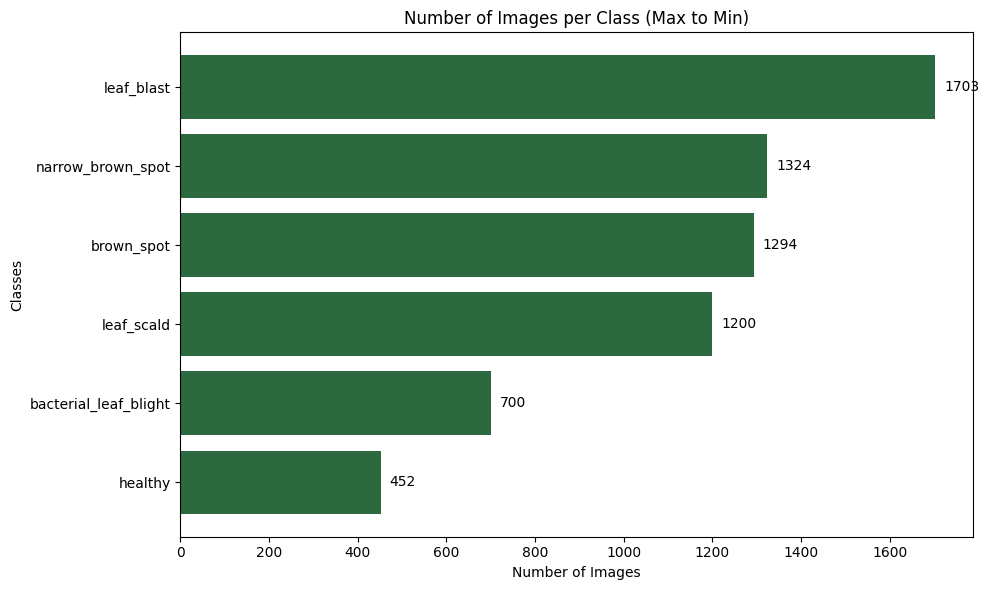

In [7]:
import matplotlib.pyplot as plt

# Class names and number of images
class_names = [
    "bacterial_leaf_blight",
    "brown_spot",
    "healthy",
    "leaf_blast",
    "leaf_scald",
    "narrow_brown_spot"
]

num_images = [700, 1294, 452, 1703, 1200, 1324]

# Sort descending
sorted_pairs = sorted(zip(num_images, class_names), reverse=True)
num_images_sorted, class_names_sorted = zip(*sorted_pairs)

# Plot horizontal bar chart
plt.figure(figsize=(10,6))
bars = plt.barh(class_names_sorted, num_images_sorted, color='#2d693f')
plt.xlabel("Number of Images")
plt.ylabel("Classes")
plt.title("Number of Images per Class (Max to Min)")

# Add numbers on the right of bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + 20, bar.get_y() + bar.get_height()/2, int(width), va='center')

plt.gca().invert_yaxis()  # Largest on top
plt.tight_layout()
plt.show()

In [5]:
import pandas as pd
import numpy as np
import joblib

# ---- Step 1: Load the trained model and scaler ----
rf = joblib.load('model_rf/multioutput_random_forest.pkl')         # Your saved MultiOutputRegressor
scaler = joblib.load('model_rf/trained_scaler.pkl')    # Your saved StandardScaler

# ---- Step 2: Define custom input with correct feature order ----
custom_input = pd.DataFrame([{
    'ph': 7.61,
    'organic_matter': 1.79,
    'zinc': 0.47,
    'total_nitrogen': 0.09,
    'potassium': 191.61,
    'p2o5': 43.77,
    'sand': 30.78,
    'clay':19.23,
    'slit': 53.03
}])[['ph', 'organic_matter', 'zinc', 'total_nitrogen', 'potassium', 'p2o5', 'sand', 'clay', 'slit']]

# ---- Step 3: Apply preprocessing (log and scaling) ----
custom_input['organic_matter'] = np.log1p(custom_input['organic_matter'])
custom_input['total_nitrogen'] = np.log1p(custom_input['total_nitrogen'])
custom_input['p2o5'] = np.log1p(custom_input['p2o5'])
custom_input['sand'] = np.log1p(custom_input['sand'])
custom_input['zinc'] = np.log1p(custom_input['zinc'])

custom_input[['potassium', 'zinc', 'slit']] = scaler.transform(
    custom_input[['potassium', 'zinc', 'slit']]
)

# ---- Step 4: Predict ----
prediction = rf.predict(custom_input)

# ---- Step 5: Output ----
print("Predicted [N, P, K] values:", prediction[0])


Predicted [N, P, K] values: [1.62013016 2.74484571 2.74484571 3.38183658 2.32571008]
